In [1]:
# Importer les bibliothèques necessaires
!pip install gdown
import gdown
import pandas as pd
import re
import gc
import os
import sys
import pandas as pd
import numpy as np
import tqdm
import seaborn as sns

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from scipy.stats import chi2_contingency
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, roc_curve, auc, classification_report, confusion_matrix, roc_auc_score
from sklearn.svm import SVC

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [gdown]


In [2]:
np.random.seed(123)

In [3]:
# Charger les données
df = pd.read_csv('Fraud Detection Dataset.csv')  # changer le nom du fichier si nécessaire
print('Forme du dataset chargé :', df.shape)
print(df['Fraudulent'].value_counts())


Forme du dataset chargé : (51000, 12)
Fraudulent
0    48490
1     2510
Name: count, dtype: int64


# **Sommaire**

### Traitement des valeurs manquantes Na
1. 1ère méthode : moyenne
2. 2ème méthode : Interpolation Bayesienne

### Implémentation des modèles de classification
1. *RandomForest*
2. *Régression Logistique*
3. *SVM*
4. *LightGBM*

### Algorithme de génération de données synthétiques : SMOTE

0. Implémentation SMOTE

### Résultats **sans SMOTE**
1. Mesures d'évaluation des modèles
2. Comparaison des courbes ROC et AUC 


### Résultats **avec SMOTE**
1. Mesures d'évaluation des modèles
2. Comparaison des courbes ROC et AUC 



## **Traitement des valeurs manquantes Na**


### **1ère méthode : moyenne**

Implémentation fonction *missing_mean*

In [4]:

def missing_mean(df):
    """
    entrée : dataset df avec valeurs manquantes Na 
    sortie :df_mean dataset traité 
    """

    # Séparation des colonnes numériques et catégorielles
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Fraudulent')
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns

    # Création d'une copie de sécurité
    df_c = df.copy()
    
    # Remplacement des valeurs manquantes pour les variables numériques
    for col in numeric_cols:
        for fraud_value in [0, 1]:
            mean_value = df_c.loc[df_c['Fraudulent'] == fraud_value, col].mean()
            df_c.loc[(df_c['Fraudulent'] == fraud_value) & (df_c[col].isna()),col] = mean_value
    
    # Remplacement des valeurs manquantes pour les variables catégorielles
    for col in categorical_cols:
        for fraud_value in [0, 1]:
            mode_series = df_c.loc[df_c['Fraudulent'] == fraud_value, col].mode()
            if not mode_series.empty:
                mode_value = mode_series.iloc[0]
                df_c.loc[(df_c['Fraudulent'] == fraud_value) & (df_c[col].isna()),col] = mode_value
    
    # Vérification du remplissage
    print("Pourcentage de valeurs manquantes après traitement :")
    print((df_c.isnull().mean() * 100).round(3))

    return df_c


### **2ème méthode : Interpolation Bayesienne**

Implémentation fonction *missing_mean*

In [5]:

"""
Le code à rentrer ici prend en entrée "df" déjà définie juste avant et renvoie "df_interpolation"

"""

# 1) IMPUTATION BAYÉSIENNE POUR VARIABLES NUMÉRIQUES

def bayesian_impute_numeric(df, num_cols=None, alpha=1.0, random_state=None):

    if random_state is not None:
        np.random.seed(random_state)

    df_out = df.copy()

    # Sélection automatique des colonnes numériques si non spécifiée
    if num_cols is None:
        num_cols = df_out.select_dtypes(include=[np.number]).columns.tolist()

    # Imputation colonne par colonne
    for col in num_cols:
        if df_out[col].isna().sum() == 0:
            continue  # Rien à imputer

        print(f"\n--- Imputation bayésienne de la colonne numérique : {col} ---")

        # Séparation Observé / Manquant
        mask_obs = df_out[col].notna()
        mask_miss = df_out[col].isna()

        y_obs = df_out.loc[mask_obs, col].values

        X_obs = df_out.loc[mask_obs, num_cols].copy()
        X_miss = df_out.loc[mask_miss, num_cols].copy()

        # Remplacer éventuels NaN des prédicteurs par leur moyenne
        X_obs = X_obs.fillna(X_obs.mean())
        X_miss = X_miss.fillna(X_obs.mean())

        # Matrices numpy
        Xo = X_obs.values
        Xm = X_miss.values

        # Ridge posterior : beta_hat = (X'X + αI)^(-1) X'y
        XtX = Xo.T @ Xo
        XtY = Xo.T @ y_obs

        Sigma_beta = np.linalg.inv(XtX + alpha * np.eye(Xo.shape[1]))
        beta_hat = Sigma_beta @ XtY

        # Variance résiduelle
        residuals = y_obs - Xo @ beta_hat
        sigma2 = residuals.var()

        # Variance prédictive (approx)
        pred_var = sigma2 + np.sum(Xm @ Sigma_beta * Xm, axis=1)

        # Moyenne prédictive
        pred_mean = Xm @ beta_hat

        # Tirage Monte-Carlo
        y_draws = np.random.normal(pred_mean, np.sqrt(pred_var))

        # Injection des valeurs imputées
        df_out.loc[mask_miss, col] = y_draws

    return df_out

# 2) IMPUTATION BAYÉSIENNE POUR VARIABLES CATÉGORIELLES

def categorical_dirichlet_impute(df, cat_cols=None, alpha0=1.0, random_state=None):

    if random_state is not None:
        np.random.seed(random_state)

    df_out = df.copy()
    info = {}

    if cat_cols is None:
        cat_cols = df_out.select_dtypes(include=['object','category']).columns.tolist()

    for col in cat_cols:
        n_missing = df_out[col].isna().sum()
        if n_missing == 0:
            continue

        print(f"\n--- Imputation Dirichlet-Multinomial : {col} ---")

        observed = df_out[col].dropna().astype(str)
        counts = observed.value_counts().to_dict()

        categories = list(counts.keys())
        counts_arr = np.array(list(counts.values()), dtype=float)

        # Prior Dirichlet symétrique
        alpha = np.ones_like(counts_arr) * alpha0

        # Posterior = counts + prior
        posterior = counts_arr + alpha
        probs = posterior / posterior.sum()

        # Tirage pour chaque NA
        draws = np.random.choice(categories, size=n_missing, p=probs)

        # Injection
        missing_indices = df_out.index[df_out[col].isna()]
        df_out.loc[missing_indices, col] = draws

        info[col] = {
            "n_missing": n_missing,
            "categories": counts,
            "probs": dict(zip(categories, probs))
        }

    return df_out, info


def missing_interpolation(df):
    """
    entrée : dataset df avec valeurs manquantes Na
    sortie : dataset df_interpolation avec valeurs manquantes Na remplacées
    """
    # 1) Imputation numérique bayésienne
    df_num = bayesian_impute_numeric(df, alpha=1.0, random_state=123)

    # 2) Imputation catégorielle Dirichlet-Multinomial
    cat_cols = ["Device_Used", "Location", "Payment_Method"]

    df_traite, infos = categorical_dirichlet_impute(df_num, cat_cols, alpha0=1.0, random_state=123)

    return df_traite


#df_final.to_csv("Fraud_Dataset_imputed_full.csv", index=False)



Preprocessing : 
Séparation des variables explicatives X de la variable expliquée y 

In [6]:
df_mean=missing_mean(df)
y = df_mean['Fraudulent']
X = df_mean.drop(columns=['Fraudulent'])

Pourcentage de valeurs manquantes après traitement :
Transaction_ID                      0.0
User_ID                             0.0
Transaction_Amount                  0.0
Transaction_Type                    0.0
Time_of_Transaction                 0.0
Device_Used                         0.0
Location                            0.0
Previous_Fraudulent_Transactions    0.0
Account_Age                         0.0
Number_of_Transactions_Last_24H     0.0
Payment_Method                      0.0
Fraudulent                          0.0
dtype: float64


/tmp/ipykernel_4978/984645087.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3002.9993194473086' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_c.loc[(df_c['Fraudulent'] == fraud_value) & (df_c[col].isna()),col] = mean_value
/tmp/ipykernel_4978/984645087.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.9953598680140234' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_c.loc[(df_c['Fraudulent'] == fraud_value) & (df_c[col].isna()),col] = mean_value
/tmp/ipykernel_4978/984645087.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '59.98537842854197' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_c.loc

In [7]:
# Encodage des colonnes catégorielles
for col in X.select_dtypes(include=['object','category']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

### **Implémentation des modèles de classification**


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
random_state=42, stratify=y)

### 1. *RandomForest*

In [9]:
def random_forest(A,b,T,t):
    """
    entrée :

    • (A,b) est le dataset d'entrainement 

    • (T,t) est le dataset de test

    sortie :

    • y_pred, y_pred_proba

    On suppose avoir déjà séparé le dataset en train et test
    """
    
    # entraînement du modèle
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(A, b)
    
    #construction de y_pred
    y_pred=clf.predict(T)
    
    #Regardons la distribution de probabilité qu'une transaction soit frauduleuse 
    y_pred_proba = clf.predict_proba(T)
    
    #On trace un histogramme de ces probas
    #pd.Series(y_pred_proba[:,1]).hist()

    return y_pred, y_pred_proba



### 2. *Régression Logistique*

Implémentation fonction *logistic*

In [10]:
def logistic(A,b,T,t):
    """
    entrée :

    • (A,b) est le dataset d'entrainement 

    • (T,t) est le dataset de test

    sortie :

    • courbe ROC avec AUC
    • threshold intéressant et les métriques associées

    On suppose avoir déjà séparé le dataset en train et test
    """
    
    #import LogisticRegression et on fit au modèle
    from sklearn.linear_model import LogisticRegression
    lr = LogisticRegression()
    lr.fit(A,b)
    
    #construction de y_pred
    y_pred=lr.predict(T)
    
    
    #Regardons la distribution de probabilité qu'une transaction soit frauduleuse 
    y_pred_proba = lr.predict_proba(T)
    
    #On trace un histogramme de ces probas
    #pd.Series(y_pred_proba[:,1]).hist()

    return y_pred, y_pred_proba


    

### 3. *SVM*

In [47]:
def svm(A,b,T,t):
    """
    entrée :

    • (A,b) est le dataset d'entrainement 

    • (T,t) est le dataset de test

    sortie :

    • y_pred, y_pred_proba

    On suppose avoir déjà séparé le dataset en train et test
    """
    
    # entraînement du modèle
    svc =SVC(kernel = 'rbf', C= 5, gamma= 'scale', probability=True )
    svc.fit(A,b)

    
    #construction de y_pred
    y_pred=svc.predict(T)
    
    #Regardons la distribution de probabilité qu'une transaction soit frauduleuse 
    y_pred_proba = svc.predict_proba(T)
    
    #On trace un histogramme de ces probas
    #pd.Series(y_pred_proba[:,1]).hist()

    return y_pred, y_pred_proba



### 4. *LightGBM*

In [53]:

def light_gbm(A,b,T,t):
    """
    entrée :

    • (A,b) est le dataset d'entrainement 

    • (T,t) est le dataset de test

    sortie :

    • y_pred, y_pred_proba

    On suppose avoir déjà séparé le dataset en train et test
    """
    
    # entraînement du modèle
    lgbm = GradientBoostingClassifier(n_estimators=500,learning_rate=0.05,max_depth=int(np.log2(31)),random_state=42)
    lgbm.fit(A, b)

    
    #construction de y_pred
    y_pred=lgbm.predict(T)
    
    #Regardons la distribution de probabilité qu'une transaction soit frauduleuse 
    y_pred_proba = lgbm.predict_proba(T)
    
    #On trace un histogramme de ces probas
    #pd.Series(y_pred_proba[:,1]).hist()

    return y_pred, y_pred_proba



### **Algorithme de génération de données synthétiques : SMOTE**

0. Implémentation fonction *smote*

In [13]:
!pip install imblearn 

def smote(A,b,p):
    """
    (A,b) : dataset auquel est appliqué l'algorithme avec A les observations 
    des variables explicatives et b celles de la variable expliquée. 

    p : proportion de la classe minoritaire

    Remarques : On suppose ici que le dataset est traité, i.e que les valeurs manquantes
    ont été remplacées
    
    """
    P=A.reset_index(drop=True)
    q=b.reset_index(drop=True)


    try:
        #On exécute l'algorithme à partir du package imblearn
        from imblearn.over_sampling import SMOTE
        #On créer le modèle smote
        sm = SMOTE(sampling_strategy=p/(1-p), random_state=42) 
        #On applique smote au dataset (X,y) avec la méthode fit_resample
        X_res, y_res = sm.fit_resample(P, q) 
        #On vérifie que les classes ont bien été rééquilibrées
        print('Après SMOTE, comptes :', np.bincount(y_res.astype(int))) 


    #Si la première exécution a rencontré un problème
    except Exception as e:
        print('imblearn non disponible, SMOTE manuel.')
        # Version manuelle (comme avant)
        from sklearn.neighbors import NearestNeighbors
        X_np = P.values
        y_np = q.values
        minority_idx = np.where(y_np==1)[0]
        X_min = X_np[minority_idx]
        print(len(X_min))
        
        # SMOTE manuel
        n_majority = np.sum(y_np==0)
        target_ratio = p
        n_samples_needed = int(p*len(A) - len(X_min))
        print(n_samples_needed)
        
        
        neigh = NearestNeighbors(n_neighbors=5).fit(X_min)
        rng = np.random.RandomState(42)
        X_res,y_res=P,q
        for i in range(n_samples_needed):
            synthetic = []
            idx = rng.randint(0, X_min.shape[0])
            nn = neigh.kneighbors([X_min[idx]], return_distance=False)[0]
            nn_choice = rng.choice(nn[1:]) if len(nn) > 1 else nn[0]
            diff = X_min[nn_choice] - X_min[idx]
            gap = rng.rand()
            synthetic.append(X_min[idx] + gap * diff)
            #X_res = np.vstack([A, np.array(synthetic)])
            #y_res = np.hstack([b, np.ones(len(synthetic))])
            X_res=pd.concat([X_res, pd.DataFrame(synthetic,columns=P.columns)], axis = 0,ignore_index=True)
            y_res=pd.concat([y_res, pd.Series(1)], axis = 0, ignore_index=True)
        print('Après SMOTE manuel p, nouvelles formes :', X_res.shape, np.bincount(y_res.astype(int)))


def smote_bis(A,b,p):
    P=A.reset_index(drop=True)
    q=b.reset_index(drop=True)
    
    #On exécute l'algorithme à partir du package imblearn
    from imblearn.over_sampling import SMOTE
    #On créer le modèle smote
    sm = SMOTE(sampling_strategy=p/(1-p), random_state=42) 
    #On applique smote au dataset (X,y) avec la méthode fit_resample
    X_res, y_res = sm.fit_resample(P, q) 
    #On vérifie que les classes ont bien été rééquilibrées
    print('Après SMOTE, comptes :', np.bincount(y_res.astype(int)))




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imblearn]d-learn]


### **Métriques d'évaluation des modèles et courbes ROC (et AUC)**

1. Implémentation fonction résultat métriques

In [39]:
def metrics(y_pred,y_pred_proba,T,t):
    """
    entrée :

    • y_pred : valeurs prédites de la variable y
    • y_pred_proba : distribution de probabilité d'appartenance au deux classes des observations 
    X_test

    • (T,t) est le dataset de test

    sortie :

    • threshold intéressant, métriques associées + matrice de confusion

    On suppose avoir déjà séparé le dataset en train et test
    """
    

    #Tracé de la courbe ROC
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, auc, roc_auc_score

    """
    fpr : FP rate
    tpr : TP rate
    ths : threshold
    """  

    #La fonction roc_curve permet de tracer la courbe ROC 
    # à partir d'un vecteur de probabilités de la classe positive (ici (fraudulent=1))
    fpr, tpr, ths = roc_curve(t, y_pred_proba[:,1])
    auc_score = auc(fpr,tpr)
    #plt.plot(fpr,tpr,label="AUC Score:" + str(auc_score))
    #plt.xlabel('FALSE POSITIVE rate',fontsize='15')
    #plt.ylabel('TRUE POSITIVE rate',fontsize='15')
    #plt.legend(loc='best')





    #Recherche d'un seuil (threshold) idéal 
    """
    On souhaiterait maximiser le taux de détection d'une transaction frauduleuse
    tout en minimisant le taux de transaction non frauduleuses classées comme tel

    On va pour cela agir sur le seuil de classification (threshold)

    On va pour cela utiliser l'indice de Youden qui va nous permettre d'obtenir un 
    seuil de façon optimale selon l'indice de Youden. 
    """

    ###________ Au seuil optimal obtenu grâce à l'indice de Youden_________ ###
    """
    On va maximiser la quantité : recall + specificty - 1 
    On en tirera un seuil optimal noté threshold_y
    On s'intéressera aux métrques associées à ce seuil afin de les comparer à
    celles sans l'indice de Youden

    """
    youden= tpr - fpr
    index_max= np.where(youden==np.max(youden))
    threshold_index= np.max(index_max)
    threshold=ths[threshold_index]

    #On obtient de même de nouvelles valeurs prédites ajustées
    from sklearn.preprocessing import binarize
    from sklearn.metrics import confusion_matrix, f1_score
    y_pred_th= binarize(y_pred_proba, threshold=threshold)
    confusion_mat = confusion_matrix(t, y_pred_th[:,1],labels=[1,0])

    #Les métriques associées avec Youden
    recall=tpr[threshold_index]
    precision=(confusion_mat[0,0])/(confusion_mat[0,0] + confusion_mat[1,0])
    specificity=1-fpr[threshold_index]
    f_score=2*precision*recall/(precision+recall)


    ###________  Au seuil de 50% (par défaut)_________  ###

    #Mesure de l'accuracy du modèle au seuil de 50%
    from sklearn.metrics import accuracy_score
    accuracy=accuracy_score(t,y_pred)

    #Matrice de confusion au seuil de 50%
    confusion_matrix(y_test, y_pred,labels = [1,0])

    #Les métriques au seuil de 50%
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    fscore = f1_score(y_test, y_pred)


    #Affichage métriques au seuil obtenu grâce à l'indice de Youden
    print("threshold avec Youden: " + str(threshold) )
    print("recall (sensitivity) avec Youden : " + str(recall) )
    print("precision avec Youden:" + str(precision))
    print("specificity avec Youden: " + str(specificity) )
    print("f1-score avec Youden : " + str(fscore))
    print("Indice de Youden: " + str(youden[threshold_index]))


    #Affichage métriques au seuil de 50%
    print("accuracy:" +str(accuracy))
    print("recall (sensitivity) au seuil de 50% : " + str(rec) )
    print("precision au seuil de 50%:" + str(prec))
    print("f1-score au seuil de 50% : " + str(f_score))





2. Implémentation fonction de tracé des courbes ROC

In [43]:
def roc(y_pred,y_pred_proba,T,t):
    """
    entrée :

    • y_pred : valeurs prédites de la variable y
    • y_pred_proba : distribution de probabilité d'appartenance au deux classes des observations 
    X_test

    • (T,t) est le dataset de test

    sortie :

    • threshold intéressant et les métriques associées

    On suppose avoir déjà séparé le dataset en train et test
    """

    #Tracé de la courbe ROC
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, auc, roc_auc_score

    """
    fpr : FP rate
    tpr : TP rate
    ths : threshold
    """  

    #La fonction roc_curve permet de tracer la courbe ROC 
    # à partir d'un vecteur de probabilités de la classe positive (ici (fraudulent=1))
    fpr, tpr, ths = roc_curve(t, y_pred_proba[:,1])
    auc_score = auc(fpr,tpr)
   
    #Mesure de l'accuracy du modèle
    from sklearn.metrics import accuracy_score
    accuracy=accuracy_score(t,y_pred)

    #Affichage AUC
    print("accuracy:" +str(accuracy))
    print("AUC: "+ str(auc_score))
    print(classification_report(y_test, y_pred))

    # Tracé effectif de la courbe ROC
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1],'--')
    plt.xlabel('Taux de Faux Positifs')
    plt.ylabel('Taux de Vrais Positifs')
    plt.title('Courbe ROC (AUC = %.3f)' % auc_score)
    plt.show()



### **Résultats sans SMOTE**

1. **Mesures** d'évaluation des modèles *(precision, accuracy, recall, specificity, f1-score)*

RandomForest

threshold avec Youden: 0.09
recall (sensitivity) avec Youden : 0.3286852589641434
precision avec Youden:0.0953360768175583
specificity avec Youden: 0.8204784491647763
f1-score avec Youden : 0.14074074074074075
Indice de Youden: 0.14916370812891966
accuracy:0.9545098039215686
recall (sensitivity) au seuil de 50% : 0.07569721115537849
precision au seuil de 50%:1.0
f1-score au seuil de 50% : 0.14780182247025922
accuracy:0.9545098039215686
AUC: 0.6017273451050407
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9698
           1       1.00      0.08      0.14       502

    accuracy                           0.95     10200
   macro avg       0.98      0.54      0.56     10200
weighted avg       0.96      0.95      0.94     10200



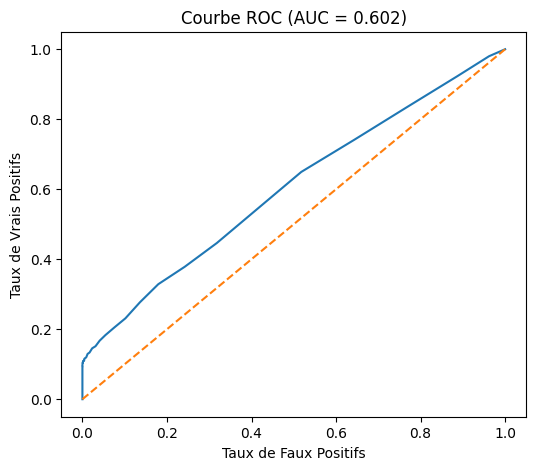

In [44]:
modele=random_forest
y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
metrics(y_pred, y_pred_proba,X_test, y_test)
roc(y_pred, y_pred_proba,X_test, y_test)

Régression Logistique

threshold avec Youden: 0.039331668139535876
recall (sensitivity) avec Youden : 0.6792828685258964
precision avec Youden:0.052011626128193364
specificity avec Youden: 0.3610022685089709
f1-score avec Youden : 0.0
Indice de Youden: 0.04028513703486725
accuracy:0.9507843137254902
recall (sensitivity) au seuil de 50% : 0.0
precision au seuil de 50%:0.0
f1-score au seuil de 50% : 0.09662483951767588
accuracy:0.9507843137254902
AUC: 0.5105001729522414
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9698
           1       0.00      0.00      0.00       502

    accuracy                           0.95     10200
   macro avg       0.48      0.50      0.49     10200
weighted avg       0.90      0.95      0.93     10200



/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWar

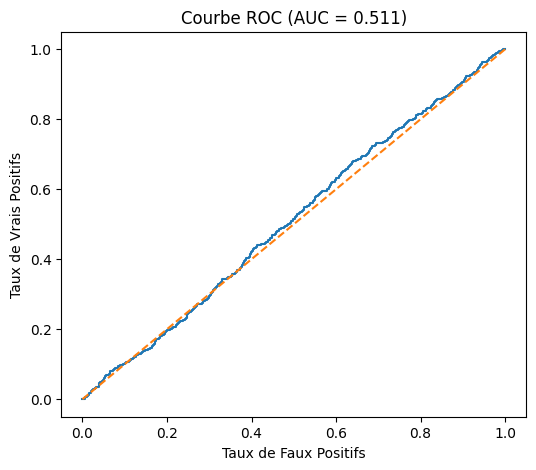

In [45]:
modele=logistic
y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
metrics(y_pred, y_pred_proba,X_test, y_test)
roc(y_pred, y_pred_proba,X_test, y_test)

SVM

threshold avec Youden: 0.05083992869549643
recall (sensitivity) avec Youden : 0.8904382470119522
precision avec Youden:0.050820419325433
specificity avec Youden: 0.14106001237368526
f1-score avec Youden : 0.0
Indice de Youden: 0.03149825938563744
accuracy:0.9507843137254902
recall (sensitivity) au seuil de 50% : 0.0
precision au seuil de 50%:0.0
f1-score au seuil de 50% : 0.09615304849757546
accuracy:0.9507843137254902
AUC: 0.49756161988466013
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9698
           1       0.00      0.00      0.00       502

    accuracy                           0.95     10200
   macro avg       0.48      0.50      0.49     10200
weighted avg       0.90      0.95      0.93     10200



/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/s

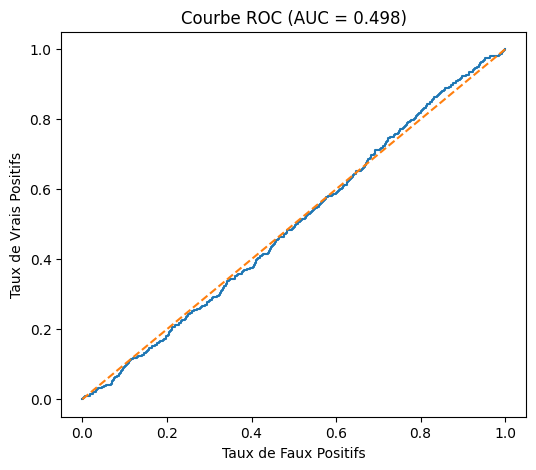

In [49]:
modele=svm
y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
metrics(y_pred, y_pred_proba,X_test, y_test)
roc(y_pred, y_pred_proba,X_test, y_test)

LightGBM

threshold avec Youden: 0.04273808325545675
recall (sensitivity) avec Youden : 0.5956175298804781
precision avec Youden:0.06429341963322546
specificity avec Youden: 0.5527943905959991
f1-score avec Youden : 0.15970961887477314
Indice de Youden: 0.14841192047647728
accuracy:0.9546078431372549
recall (sensitivity) au seuil de 50% : 0.08764940239043825
precision au seuil de 50%:0.8979591836734694
f1-score au seuil de 50% : 0.11605895558402332
accuracy:0.9546078431372549
AUC: 0.6182898843890267
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9698
           1       0.90      0.09      0.16       502

    accuracy                           0.95     10200
   macro avg       0.93      0.54      0.57     10200
weighted avg       0.95      0.95      0.94     10200



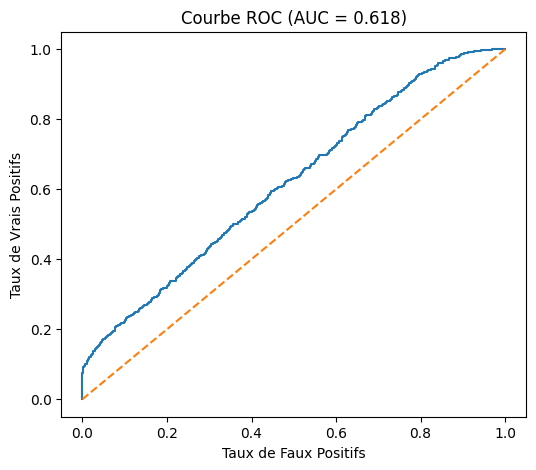

In [54]:
modele=light_gbm
y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
metrics(y_pred, y_pred_proba,X_test, y_test)
roc(y_pred, y_pred_proba,X_test, y_test)

### **Résultats avec SMOTE**

1. **Mesures** d'évaluation des modèles *(precision, accuracy, recall, specificity, f1-score)*

RandomForest

Régression Logistique

SVM

LightGBM